# GranData TEST | Nava Mendez Gabriel Tadeo 
### Workflow:
#####  0. Importing libraries and creating session
##### 1. Reading customer_attributes dataset
##### 2. Reading call_detail_record dataset
##### 3. Null treatement 
##### 4. Duplicates
##### 5. Casting 
##### 6. Outliers
##### 7. Aggregate Functions
##### 8. Joins
##### 9. Exploratoy Data Analaysis
##### 10. Feature Selection
##### 11. Model 

## ---------------------------------------------------------------------------------------------------

## 0. Importing libraries and initializing session

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.combine import SMOTETomek

import warnings
warnings.filterwarnings("ignore")

from pyspark.sql import SparkSession
from pyspark.sql import DataFrame
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType


spark = SparkSession.builder \
    .appName("Grandata_TEST") \
    .master("local[*]") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/23 23:19:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 1. Reading customer_attributes dataset

In [2]:
# Loading dataset
df_customers = spark.read.parquet("/home/tadeo/Documentos/VS_Code/02 - Scripts/GrandData exercise/Data/customer_attributes")


def schema_and_sample(df, truncate):
    print(f"Total records: {df.count()}") 
    print("Schema of the DataFrame:")
    df.printSchema()
    print("Sample records:")
    df.show(5, truncate=truncate)
    
schema_and_sample(df_customers, truncate = False)
   

Total records: 10274
Schema of the DataFrame:
root
 |-- id: string (nullable = true)
 |-- region: string (nullable = true)
 |-- device: string (nullable = true)
 |-- default: string (nullable = true)

Sample records:
+--------------------------------+--------+---------------------------------+-------+
|id                              |region  |device                           |default|
+--------------------------------+--------+---------------------------------+-------+
|48685349675170704955706848526668|REGION H|REDMI - NOTE 10 PRO              |0      |
|48685750554849535269546655535170|REGION F|SAMSUNG - GALAXY NOTE 8 N950U    |0      |
|49485348694854495470704853575467|REGION I|SAMSUNG - GALAXY A02S A025M      |1      |
|49555167666549495265555054705065|REGION G|APPLE - IPHONE 11 A2221          |0      |
|49575349657049667054685365706867|REGION G|MOTOROLA - MOTO G7 POWER XT1955-2|0      |
+--------------------------------+--------+---------------------------------+-------+
only show

## 2. Reading call_detail_record (100 parquet files) dataset

In [3]:
# Loading dataset
df_calldetail = spark.read.parquet("/home/tadeo/Documentos/VS_Code/02 - Scripts/GrandData exercise/Data/call_detail_record")

schema_and_sample(df_calldetail, truncate = False)

Total records: 1051192
Schema of the DataFrame:
root
 |-- date: string (nullable = true)
 |-- hour: integer (nullable = true)
 |-- source_id: string (nullable = true)
 |-- destination_id: string (nullable = true)
 |-- calls: integer (nullable = true)
 |-- duration: integer (nullable = true)
 |-- messages: integer (nullable = true)

Sample records:
+--------+----+--------------------------------+--------------------------------+-----+--------+--------+
|date    |hour|source_id                       |destination_id                  |calls|duration|messages|
+--------+----+--------------------------------+--------------------------------+-----+--------+--------+
|20230331|17  |54675268495170535448495353515054|50545065555652486751546970666755|1    |24      |0       |
|20230331|17  |56506869566566534870545268564857|57655757525251485270575165545251|1    |63      |0       |
|20230331|14  |54656666505550555370705366485655|50675253654856685549695757555150|1    |99      |0       |
|20230331|8   

## 3. Null Treatement

In [4]:
def audit_nulls_detailed(df):
    """
    Detailed null and NaN search per column, respecting data types.
    """

    audit_exprs = []
    for col_name, dtype in df.dtypes:
        # Standard null check for all data types
        null_cond = F.col(col_name).isNull()
        
        # Add NaN check only for numeric columns 
        if dtype in ("int"): #could consider 'double','float','long','decimal' for numeric types
            null_cond = null_cond | F.isnan(col_name)
            
        audit_exprs.append(F.count(F.when(null_cond, col_name)).alias(col_name))
    
    return df.select(audit_exprs).show()

#Function applying by dataset
print("Null/NaN count for customer_attributes:")
audit_nulls_detailed(df_customers)

print("Null/NaN count for call_detail_record:")
audit_nulls_detailed(df_calldetail)

Null/NaN count for customer_attributes:
+---+------+------+-------+
| id|region|device|default|
+---+------+------+-------+
|  0|     0|     0|      0|
+---+------+------+-------+

Null/NaN count for call_detail_record:


+----+----+---------+--------------+-----+--------+--------+
|date|hour|source_id|destination_id|calls|duration|messages|
+----+----+---------+--------------+-----+--------+--------+
|   0|   0|        0|             0|    0|       0|       0|
+----+----+---------+--------------+-----+--------+--------+



## 4. Duplicates

In [5]:
# Distinct users in both tables
unique_users_calldetail = df_calldetail.distinct().count()
total_customers = df_customers.distinct().count()

print(f"Unique users in call_detail_record: {unique_users_calldetail}")
print(f"Unique users  (Total targets) customer_attribute: {total_customers}")

Unique users in call_detail_record: 1051192
Unique users  (Total targets) customer_attribute: 10274


## 5. Casting

In [6]:
def casting_calldetailsrecord(df):
    """ 
        Cast columns into functional data format.  
    """
    df_cast_cdr = df.withColumn("date", F.to_date(F.col("date"), "yyyyMMdd")) 
    return df_cast_cdr


def casting_customerattributes(df):
    """ 
        Cast columns into functional data format.  
    """
    df_cast_ca = df.withColumn('default', F.col('default').cast(IntegerType()))
    return df_cast_ca

# Apply casting functions
df_calldetail_cast = casting_calldetailsrecord(df_calldetail)
df_customers_cast = casting_customerattributes(df_customers)

#### Comprobing efectiveness 

In [7]:
# Customer Attributes dataset
print("Schema for customer_attributes after casting:")
df_customers_cast.printSchema()
print("Null/NaN count for customer_attributes:")
audit_nulls_detailed(df_customers_cast)


# Call Detail Record dataset
print("Schema for call_detail_record after casting:")
df_calldetail_cast.printSchema()
print("Null/NaN count for call_detail_record:")
audit_nulls_detailed(df_calldetail_cast)

Schema for customer_attributes after casting:
root
 |-- id: string (nullable = true)
 |-- region: string (nullable = true)
 |-- device: string (nullable = true)
 |-- default: integer (nullable = true)

Null/NaN count for customer_attributes:
+---+------+------+-------+
| id|region|device|default|
+---+------+------+-------+
|  0|     0|     0|      0|
+---+------+------+-------+

Schema for call_detail_record after casting:
root
 |-- date: date (nullable = true)
 |-- hour: integer (nullable = true)
 |-- source_id: string (nullable = true)
 |-- destination_id: string (nullable = true)
 |-- calls: integer (nullable = true)
 |-- duration: integer (nullable = true)
 |-- messages: integer (nullable = true)

Null/NaN count for call_detail_record:


+----+----+---------+--------------+-----+--------+--------+
|date|hour|source_id|destination_id|calls|duration|messages|
+----+----+---------+--------------+-----+--------+--------+
|   0|   0|        0|             0|    0|       0|       0|
+----+----+---------+--------------+-----+--------+--------+



## 6. Outliers


#### 6.1 Physical Outliers (date & hour)

In [8]:
df_calldetail_cast.agg(F.min("date"), F.max("date")).show()

+----------+----------+
| min(date)| max(date)|
+----------+----------+
|2023-03-01|2023-03-31|
+----------+----------+



In [9]:
def filter_physical_outliers(df):
    """
    Filter out physical outliers based on logic.
    e.g. a call duration should be between 0 and 24 hours (86400 seconds).
    """
    return df.filter((F.col("messages") >= 0) & #messages can't be negative
                     (F.col("calls") >= 0) & #calls can't be negative
                     (F.col("hour") >= 0) & (F.col("hour") < 24) & #the hour of the day should be between 0 and 23
                     ((F.col("duration") >= 0) & (F.col("duration") < 3600)) &  #ir can't be a call longer than a day
                     ~((F.col("duration") > 0) & (F.col("calls") == 0)) #it can't be a call with duration > 0 and 0 calls
                     #F.col("source_id") != F.col("destination_id") #it can't be a call where source and destination are the same, but this is not necessarily an outlier, so we will not filter it out
                     )

# Apply physical outlier filtering
df_calldetail_cast = filter_physical_outliers(df_calldetail_cast)

## 7. Aggregate Functions

#####  The problem here is the relation between the two datasets. As we have more unique users in call_detail_record than in customer_attributes, and also have 2 different id columns forcing us to do two joins: one between "source_id" and "id", and another between "destination_id" and "customer_id".
##### Otherwise we have a "1:N" relation and we need "1:1" relation, so, in order to create a good dataset  we must reduce dimension of "call_detail_record" by summarizing by "id", so we will have one row per "id" with aggregated features.

In [10]:
"""
LOGIC:
    - To get one row per user, use the function "groupBy"
    - To get the total amount of call per user, we use the "sum" function. 
    - To get the total duration of calls per user, we use the "sum" function to know the amount of seconds spent by user.
    - As not only the amount of time spent on calls, is important to know the average time per call, we use the "avg" function to know the average duration per call. 
    - To get the total amount of messages per user, we use the "sum" function to know the amount of messages sent by user.
    - Regarding the hour of the day, we use the "avg" function to know the average hour of the day when the user makes calls.
    - About the date column, as the dataset is from March 2023, we will focus "counting uniqueness" of the days of activities rather than using date ranges. 
    - We also want to know the "unique contacts count" per id, so we will understand the activity of user and see consistency. 
    - In order to add granularity, we calculate and categorize calls by the hour of the day, to know if the user is more active in the morning, afternoon, night or early morning.
      While "sum" measures volume, "avg" measures intensity and is better for modelling. 
    - Also for granularity, we split day of the week by weekends or not.
    - "cv_duration": While "avg_duration" captures
      the typical call length, it does not capture consistency. A user with avg=60s could have all calls
      near 60s (stable) or a mix of 5s and 300s calls (erratic). High CV suggests irregular behavior,
      which is a known signal of financial instability in telco credit scoring.
    - "calls_per_contact": total calls divided by unique contacts. Measures network concentration —
      whether the user spreads calls across many contacts or concentrates on few. A high ratio means
      the user relies heavily on a small circle, which correlates with lower social capital and higher risk.
    - "days_active_ratio": unique active days divided by 31 (total days in March 2023). Normalizes
      activity consistency across the full observation window. A low ratio means the user was active
      only sporadically, which may indicate irregular lifestyle patterns.

NOTE: The same logic is applied for both keys: source_id and destination_id.
NOTE: nullif(..., 0) is used in all divisions to avoid zero-division errors for users with no activity
      on one side of the join. These will appear as null and should be filled with 0 downstream.
"""

# Aggregate call_detail_record by source_id to get one row per user_id
df_calldetailrecord_source_agg = df_calldetail_cast.groupBy("source_id").agg(
    F.sum("calls").alias("source_total_calls"),
    F.sum("duration").alias("source_total_duration"),
    F.avg("duration").alias("source_avg_duration"),
    F.sum("messages").alias("source_total_messages"),
    F.avg("hour").alias("source_avg_call_hour"),
    F.count_distinct("date").alias("source_avg_call_date"),
    F.count_distinct("destination_id").alias("source_unique_contacts"),
    F.avg(F.when(F.col("hour").between(0, 6), 1).otherwise(0)).alias("source_calls_earlymorning"),
    F.avg(F.when(F.col("hour").between(7, 12), 1).otherwise(0)).alias("source_calls_morning"),
    F.avg(F.when(F.col("hour").between(13, 18), 1).otherwise(0)).alias("source_calls_afternoon"),
    F.avg(F.when(F.col("hour").between(19, 23), 1).otherwise(0)).alias("source_calls_night"),
    F.avg(F.when(F.dayofweek(F.col("date")).isin([1, 7]), 1).otherwise(0)).alias("source_weekend"),
    F.avg(F.when(F.dayofweek(F.col("date")).between(2, 6), 1).otherwise(0)).alias("source_weekday"),
    (F.stddev("duration") / F.nullif(F.avg("duration"), F.lit(0))).alias("source_cv_duration"),
    (F.sum("calls") / F.nullif(F.count_distinct("destination_id"), F.lit(0))).alias("source_calls_per_contact"),
    (F.count_distinct("date") / F.lit(31)).alias("source_days_active_ratio")
)

# Aggregate call_detail_record by destination_id to get one row per user_id
df_calldetailrecord_destination_agg = df_calldetail_cast.groupBy("destination_id").agg(
    F.sum("calls").alias("destination_total_calls"),
    F.sum("duration").alias("destination_total_duration"),
    F.avg("duration").alias("destination_avg_duration"),
    F.sum("messages").alias("destination_total_messages"),
    F.avg("hour").alias("destination_avg_call_hour"),
    F.count_distinct("date").alias("destination_avg_call_date"),
    F.count_distinct("source_id").alias("destination_unique_contacts"),
    F.avg(F.when(F.col("hour").between(0, 6), 1).otherwise(0)).alias("destination_calls_earlymorning"),
    F.avg(F.when(F.col("hour").between(7, 12), 1).otherwise(0)).alias("destination_calls_morning"),
    F.avg(F.when(F.col("hour").between(13, 18), 1).otherwise(0)).alias("destination_calls_afternoon"),
    F.avg(F.when(F.col("hour").between(19, 23), 1).otherwise(0)).alias("destination_calls_night"),
    F.avg(F.when(F.dayofweek(F.col("date")).isin([1, 7]), 1).otherwise(0)).alias("destination_weekend"),
    F.avg(F.when(F.dayofweek(F.col("date")).between(2, 6), 1).otherwise(0)).alias("destination_weekday"),
    (F.stddev("duration") / F.nullif(F.avg("duration"), F.lit(0))).alias("destination_cv_duration"),
    (F.sum("calls") / F.nullif(F.count_distinct("source_id"), F.lit(0))).alias("destination_calls_per_contact"),
    (F.count_distinct("date") / F.lit(31)).alias("destination_days_active_ratio")
)

#JUST IN CASE YOU WANT TO SEE STRUCTURE
#schema_and_sample(df_calldetailrecord_source_agg, truncate = 5)
#schema_and_sample(df_calldetailrecord_destination_agg, truncate = 5)

## 8. Joining tables: comprobing consistency and null treatement

In [11]:
"""
    The firsts aggregate functions itself does not bring the sufficient granularity to the dataset, 
    so, the need for relations between features is created. The following functions are planned to 
    add more detail and provide ways to measure realtions between features. 

    "call_initiative_ratio": source_calls / (source_calls + destination_calls).
      Proportion of total activity the user INITIATES. Values near 0 = very passive,
      near 1 = very active caller, near 0.5 = balanced. 
      Hypothesis: defaulters tendtoward extremes (highly passive or overly demanding).

    "network_deepness": source_unique / destination_unique.
      Does the user call more people than call him? > 1 means broader outgoing network,
      < 1 means more people seek him out. 
      Hypothesis: extreme asymmetry suggestsunbalanced social relationships.

    "duration_distribution": source_avg_duration - destination_avg_duration.
      Are outgoing calls longer or shorter than incoming? Hypothesis: defaulters may show
      marked asymmetry — very short outgoing calls suggest low relationship investment.

    "hour_shift": |source_avg_call_hour - destination_avg_call_hour|.
      Does the user call at different hours than when he receives calls?
      Hypothesis: high shift indicates inconsistent or evasive behavior.

    "night_exposure": source_calls_night + destination_calls_night.
      Total nocturnal activity across both roles. 
      Hypothesis: high night activity correlates with unemployment.

    "weekend_consistency": 1 - |source_weekend - destination_weekend|.
      How consistent is weekend behavior as caller vs receiver?
      Hypothesis: inconsistency signals erratic behavioral patterns.

    "total_network_size": source_unique + destination_unique.
      Total contact network size across both roles. 
      Hypothesis: smaller networks correlate with lower social capital and higher default probability.

    "calls_concentration": avg of calls_per_contact for both perspectives.
      Average call concentration across source and destination.
      Hypothesis: high concentration on few contacts signals social isolation and risk.

    "has_activity": When sum of total calls > 0, assigns 1. 
      When calling, the absence is different than zero, so, before filling na's 
      with zeros, we create the column to leave evidence of absence of data. 

      NOTE: F.lit() adds a literal value (F.lit(0) assigns 0 in conditions) or a constant (f.lit(2) -> 2)
"""

df_customer_gold = (
    df_customers_cast
    # HERE WE DO THE JOINS 
    .join(df_calldetailrecord_source_agg, df_customers_cast.id == df_calldetailrecord_source_agg.source_id, "left")
    .join(df_calldetailrecord_destination_agg, df_customers_cast.id == df_calldetailrecord_destination_agg.destination_id, "left")
    # HERE WE ADD NEW COLUMNS
    .withColumns({
        "call_initiative_ratio": (F.col("source_total_calls") / F.nullif(F.col("source_total_calls") + F.col("destination_total_calls"), F.lit(0))),
        "network_deepness": (F.col("source_unique_contacts") / F.nullif(F.col("destination_unique_contacts"), F.lit(0))),
        "duration_distribution": (F.col("source_avg_duration") - F.col("destination_avg_duration")),
        "hour_shift": F.abs(F.col("source_avg_call_hour") - F.col("destination_avg_call_hour")),
        "night_exposure": (F.col("source_calls_night") + F.col("destination_calls_night")),
        "weekend_consistency": (F.lit(1) - F.abs(F.col("source_weekend") - F.col("destination_weekend"))),
        "total_network_size": (F.col("source_unique_contacts") + F.col("destination_unique_contacts")),
        "calls_concentration": ((F.col("source_calls_per_contact") + F.col("destination_calls_per_contact")) / F.lit(2)),
        "has_activity": F.when((F.col("source_total_calls") + F.col("destination_total_calls")) > 0, 1).otherwise(0)
        })
)

#JUST IN CASE YOU WANT TO SEE STRUCTURE
#schema_and_sample(df_customer_gold, truncate=15)
#audit_nulls_detailed(df_customer_gold)

In [12]:
# Stop dealing with nulls and duplicated columns
df_master_clean = df_customer_gold.drop("source_id", "destination_id", "source_weekdays", "destination_weekdays")
df_master_clean = df_master_clean.fillna(0)
audit_nulls_detailed(df_master_clean)

26/03/23 23:20:40 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---+------+------+-------+------------------+---------------------+-------------------+---------------------+--------------------+--------------------+----------------------+-------------------------+--------------------+----------------------+------------------+--------------+--------------+------------------+------------------------+------------------------+-----------------------+--------------------------+------------------------+--------------------------+-------------------------+-------------------------+---------------------------+------------------------------+-------------------------+---------------------------+-----------------------+-------------------+-------------------+-----------------------+-----------------------------+-----------------------------+---------------------+----------------+---------------------+----------+--------------+-------------------+------------------+-------------------+------------+
| id|region|device|default|source_total_calls|source_total_du

Transforming to pandas dataframe for easier manipulation

In [13]:
df_gold = df_master_clean.toPandas()
df_gold.info()
df_gold.head(3)
df_gold.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10274 entries, 0 to 10273
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              10274 non-null  str    
 1   region                          10274 non-null  str    
 2   device                          10274 non-null  str    
 3   default                         10274 non-null  int32  
 4   source_total_calls              10274 non-null  int64  
 5   source_total_duration           10274 non-null  int64  
 6   source_avg_duration             10274 non-null  float64
 7   source_total_messages           10274 non-null  int64  
 8   source_avg_call_hour            10274 non-null  float64
 9   source_avg_call_date            10274 non-null  int64  
 10  source_unique_contacts          10274 non-null  int64  
 11  source_calls_earlymorning       10274 non-null  float64
 12  source_calls_morning            10274 non-n

,default,source_total_calls,source_total_duration,source_avg_duration,source_total_messages,source_avg_call_hour,source_avg_call_date,source_unique_contacts,source_calls_earlymorning,source_calls_morning,...,destination_days_active_ratio,call_initiative_ratio,network_deepness,duration_distribution,hour_shift,night_exposure,weekend_consistency,total_network_size,calls_concentration,has_activity
count,10274.000000,10274.000000,10274.000000,10274.000000,10274.000000,10274.000000,10274.000000,10274.000000,10274.000000,10274.000000,...,10274.000000,10274.000000,10274.000000,10274.000000,10274.000000,10274.000000,10274.000000,10274.000000,10274.000000,10274.000000
mean,0.153884,54.385050,8596.071832,150.874147,4.045649,12.648474,12.818668,12.897898,0.025407,0.295493,...,0.602181,0.366084,0.797842,5.386940,1.345608,0.358476,0.755634,28.304653,3.079801,0.880572
std,0.360855,87.133451,16196.515564,180.811352,47.078828,5.022625,10.922250,17.069917,0.072170,0.234843,...,0.279691,0.273166,0.769185,183.379227,1.608651,0.282029,0.315445,29.563979,2.581057,0.324307
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-3210.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,3.000000,199.000000,47.626645,0.000000,12.576049,2.000000,2.000000,0.000000,0.096774,...,0.387097,0.090909,0.222222,-45.360846,0.267600,0.156723,0.736842,10.000000,1.587351,1.000000
50%,0.000000,18.000000,2171.000000,102.321678,0.000000,14.000000,10.000000,8.000000,0.000000,0.302356,...,0.645161,0.375921,0.656158,0.000000,0.826509,0.326753,0.887245,21.000000,2.625000,1.000000
75%,0.000000,71.000000,9770.750000,194.881192,0.000000,15.130823,24.000000,18.000000,0.020833,0.428571,...,0.838710,0.600000,1.166667,46.937400,1.832759,0.500000,0.956220,38.000000,4.032937,1.000000
max,1.000000,1197.000000,257684.000000,3463.000000,2573.000000,23.000000,31.000000,478.000000,1.000000,1.000000,...,1.000000,1.000000,13.000000,2611.678571,17.000000,2.000000,1.000000,558.000000,71.750000,1.000000


## 9. Exploratory Data Analysis

Initial exploratory analysis on the raw volumetric data (using Information Value and Weight of Evidence) revealed a weak univariate predictive signal (max(IV)<0.06). Consequently, base features alone yielded a suboptimal Gini coefficient. To extract the underlying behavioral signal, the dataset was enriched by engineering relational asymmetry features (RELATIONAL_COLS). The following pipeline evaluates this enriched feature space.

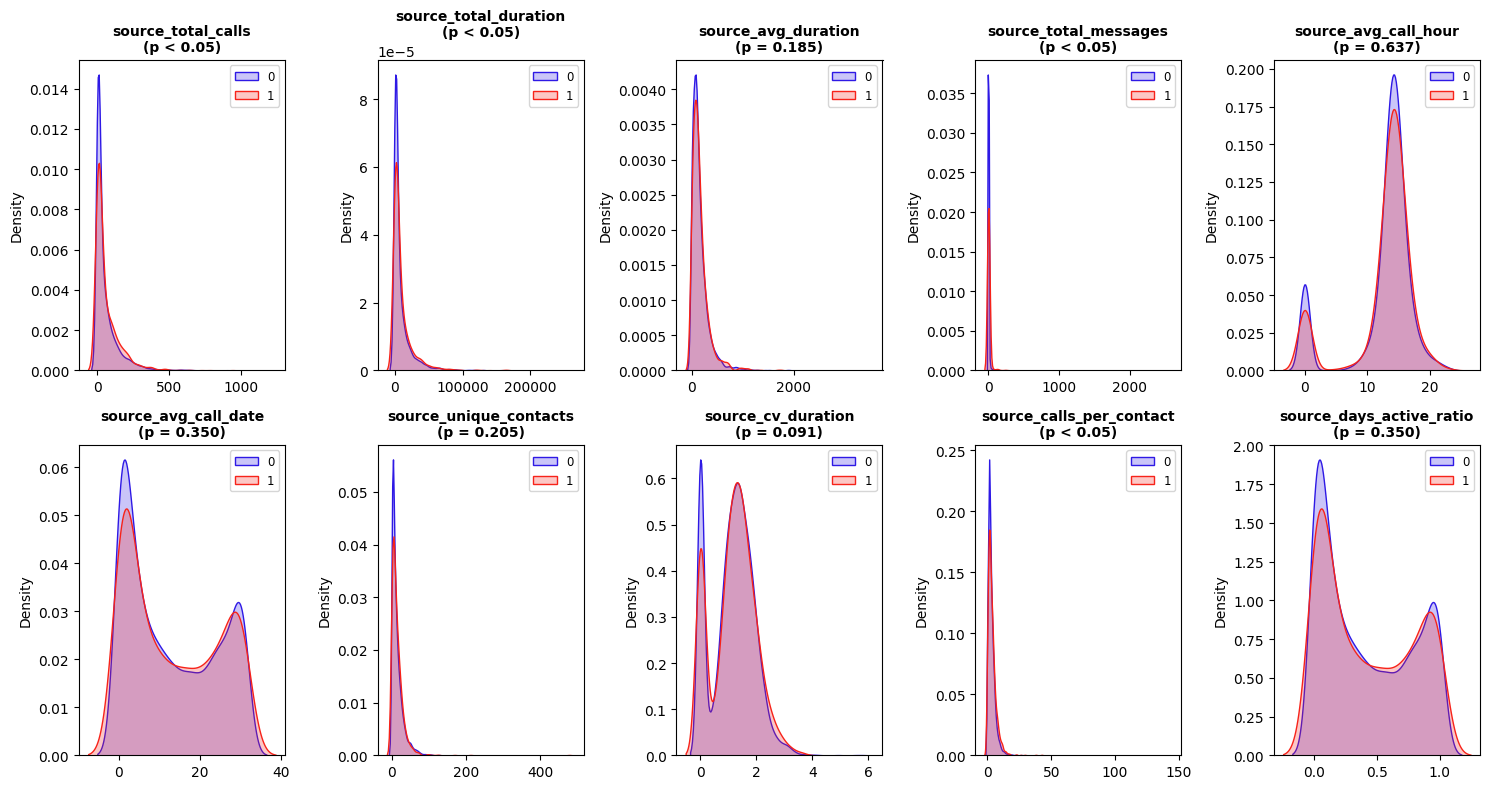

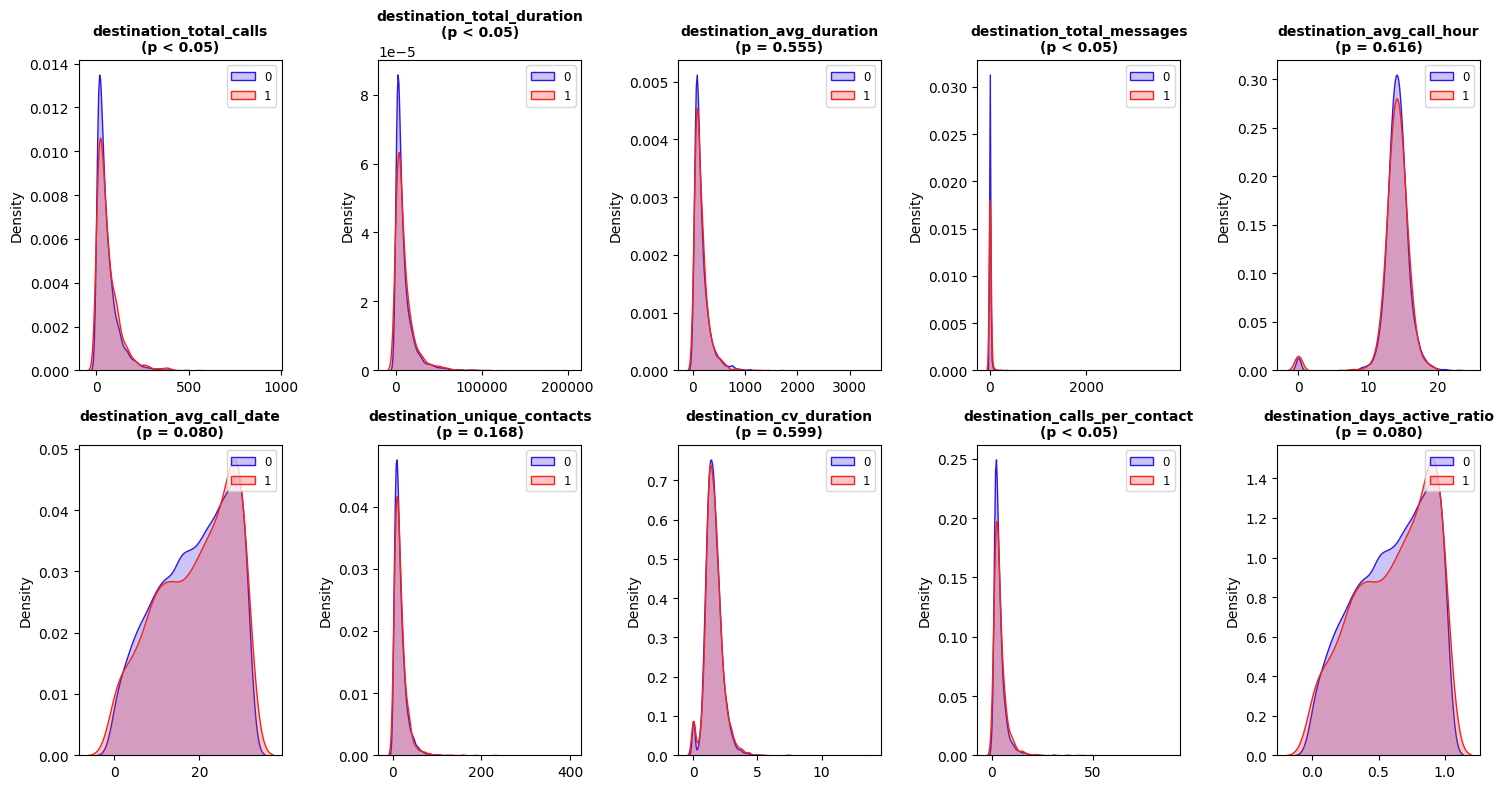

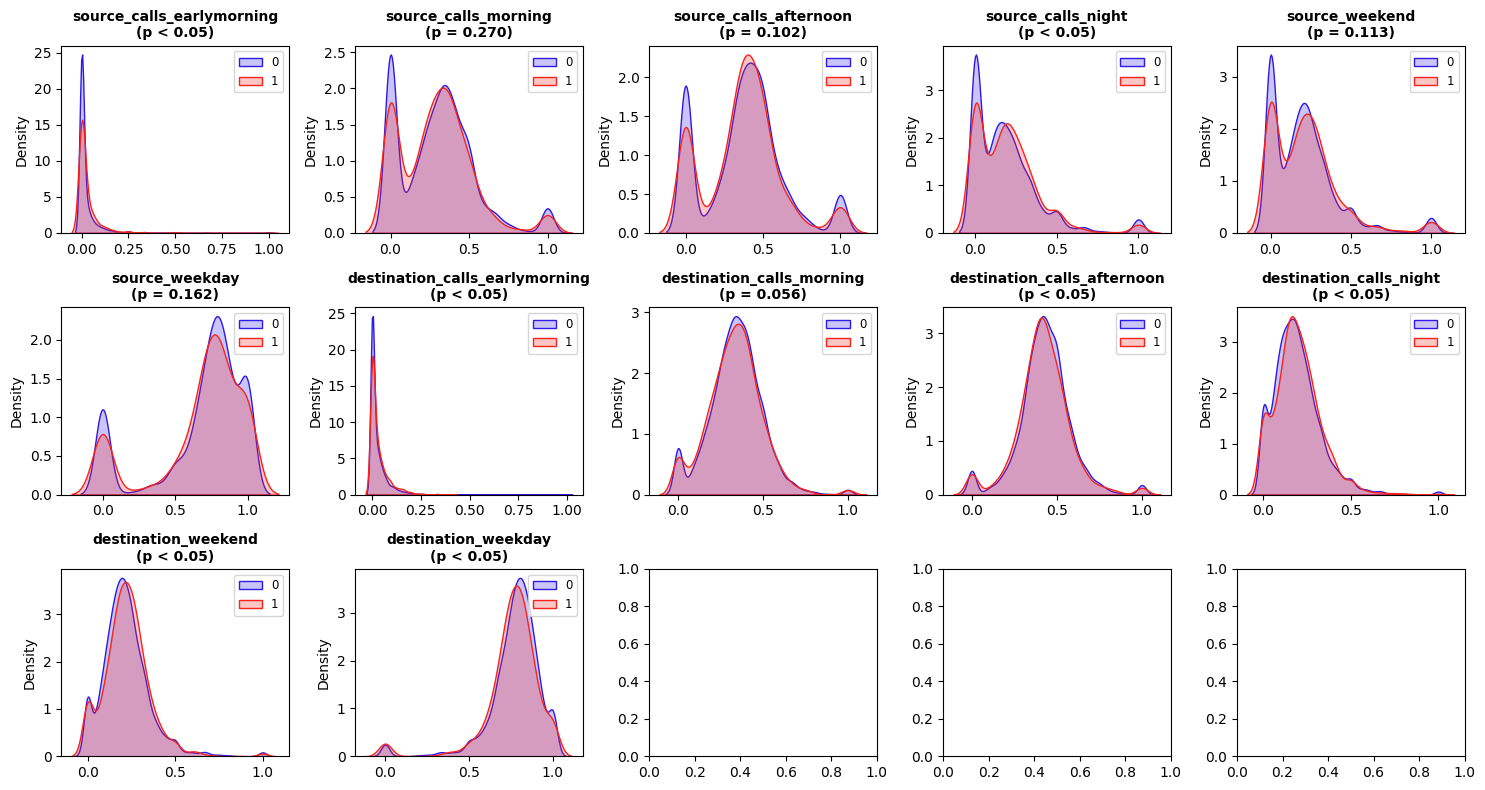

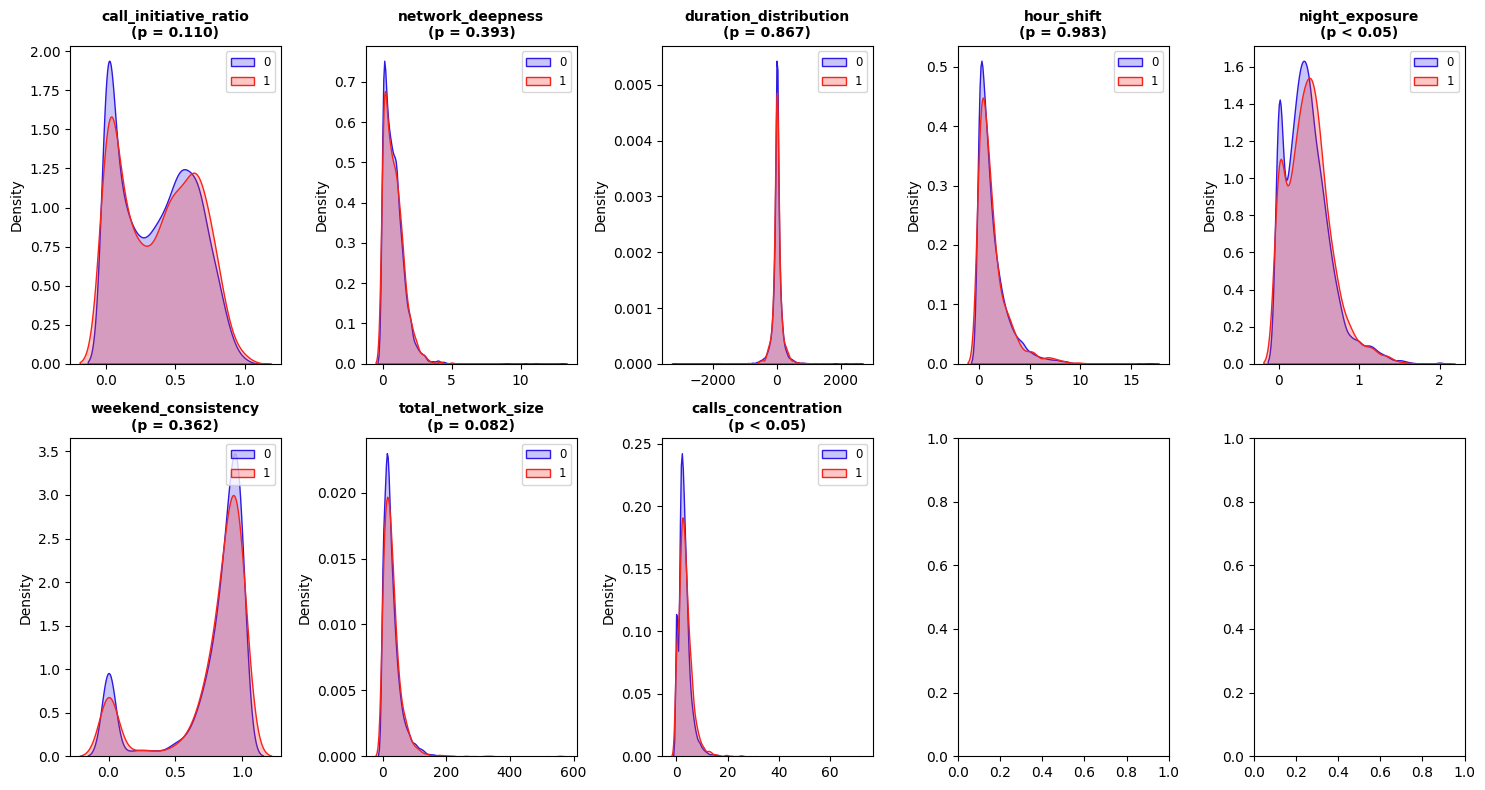

'\n    NOTE: As charts show, some features shows similar behavior between groups than others. \n    So, some features could be no weak to correctly classigy.\n'

In [14]:
"""
For each numerical feature, we plot overlapping histograms for default=0 and
default=1 groups. The goal is to visually identify features where distributions
differ between groups — these are candidates for discrimination.

Features where both distributions overlap almost completely are likely weak
predictors because implies no clarity to clasify. 
Otherwise, features where distributions shift, spread differently, or show
distinct peaks are better candidates for the model.

"""
COLOR_0, COLOR_1 = "#2e19e5", "#f7231a" #colors for the graphs 

# Group features by type for organized visualization
BASE_SOURCE_COLS = [
    "source_total_calls", "source_total_duration", "source_avg_duration",
    "source_total_messages", "source_avg_call_hour", "source_avg_call_date",
    "source_unique_contacts", "source_cv_duration", "source_calls_per_contact",
    "source_days_active_ratio"
]

BASE_DESTINATION_COLS = [
    "destination_total_calls", "destination_total_duration", "destination_avg_duration",
    "destination_total_messages", "destination_avg_call_hour", "destination_avg_call_date",
    "destination_unique_contacts", "destination_cv_duration", "destination_calls_per_contact",
    "destination_days_active_ratio"
]

TEMPORAL_COLS = [
    "source_calls_earlymorning", "source_calls_morning", "source_calls_afternoon", "source_calls_night",
    "source_weekend", "source_weekday",
    "destination_calls_earlymorning", "destination_calls_morning",
    "destination_calls_afternoon", "destination_calls_night",
    "destination_weekend", "destination_weekday"
]

RELATIONAL_COLS = [
    "call_initiative_ratio", "network_deepness", "duration_distribution",
    "hour_shift", "night_exposure", "weekend_consistency",
    "total_network_size", "calls_concentration"
] 



# DISTRIBUTIONS
def plot_histograms(df, features, target, cols=5): # cols=5 is the number of columns in the grid
    
    rows = int(np.ceil(len(features) / cols)) # the "rows" of charts per grid
    fig, axes = plt.subplots(rows, cols, figsize=(15, 8)) #creates grid space
    axes = axes.flatten()

    for i, col in enumerate(features):
        ax = axes[i]
        
        # Mann-Whitney U test for distribution between similar groups
        # Hypotheis: if p < 0.05, the distributions are significantly different, which suggests the feature has signal to categorize. 
        _, p_val = stats.mannwhitneyu(df[df[target]==0][col], df[df[target]==1][col]) # "_" means we are ignoring the output of statistic, we just want p-value
        p_txt = f"p < 0.05" if p_val < 0.05 else f"p = {p_val:.3f}"
        
        sns.kdeplot(df[df[target]==0][col], ax=ax, color=COLOR_0, fill=True, label="0", bw_adjust=1)
        sns.kdeplot(df[df[target]==1][col], ax=ax, color=COLOR_1, fill=True, label="1", bw_adjust=1)
        
        ax.set_title(f"{col}\n({p_txt})", fontsize=10, fontweight='bold')
        ax.set_xlabel("")
        ax.legend(loc='upper right', fontsize='small')
        
    plt.tight_layout()
    plt.show()

# Run for a specific group to avoid too much and non-friendly readable plots.
plot_histograms(df_gold, BASE_SOURCE_COLS, "default")
plot_histograms(df_gold, BASE_DESTINATION_COLS, "default")
plot_histograms(df_gold, TEMPORAL_COLS, "default")
plot_histograms(df_gold, RELATIONAL_COLS, "default")

"""
    NOTE: As charts show, some features shows similar behavior between groups than others. 
    So, some features could be no weak to correctly classigy.
""" 


Total records: 10274
         Count Percentage
default                  
0         8693     84.61%
1         1581     15.39%


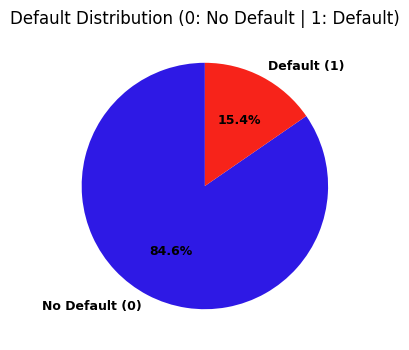

Top 10 Features Correlated with default
source_total_messages                    | rho: 0.0584
destination_calls_earlymorning           | rho: 0.0583
source_calls_earlymorning                | rho: 0.0540
calls_concentration                      | rho: 0.0536
source_calls_per_contact                 | rho: 0.0485
destination_weekday                      | rho: -0.0454
destination_total_messages               | rho: 0.0387
destination_calls_per_contact            | rho: 0.0350
destination_calls_afternoon              | rho: -0.0333
night_exposure                           | rho: 0.0328


 Top correlated columns (|rho| > 0.75)
Pair: source_total_calls        & source_total_duration     | rho: 0.9460
Pair: source_total_calls        & source_avg_call_date      | rho: 0.9772
Pair: source_total_calls        & source_unique_contacts    | rho: 0.9554
Pair: source_total_calls        & source_calls_per_contact  | rho: 0.9000
Pair: source_total_calls        & source_days_active_ratio  | rho: 0.97

In [15]:
"""
    This code analyze distribution of "default" and 
    correlation between features to discover less relevant columns.
"""

num_cols = [c for c in df_gold.columns if c not in ["id", "region", "device", "default"]] #considerates all columns except id, region, device, default

# DEFAULT BALANCE
def show_target_balance(df, target):
    """
        Summary and minimal plot for target balance
    """
    counts = df[target].value_counts()
    percent = df[target].value_counts(normalize=True)*100 #creating percent value, not just 0.xx order
    
    print(f"Total records: {len(df)}")
    print(pd.DataFrame({"Count": counts, "Percentage": percent.round(2).astype(str) + "%"}))
    
    plt.figure(figsize=(6, 4))
    plt.pie(
        counts.values,
        labels=["No Default (0)", "Default (1)"],
        colors=[COLOR_0, COLOR_1],
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 9, "weight": "bold"}
    )
    plt.title("Default Distribution (0: No Default | 1: Default)")
    plt.show()

show_target_balance(df_gold, "default")


# CORRELATION
def spearman_correlation(df, features, target, threshold):
    """
    Calculates Spearman correlation and identifies redundant pairs.
    The justification for the use of this method is the lack of linear relationship among features, 
    in this case the data is cyclic and ordinal. 
    """
    # 1. Calculate correlation matrix 
    cols = features + [target]
    corr_matrix = df[cols].corr(method='spearman').values
    col_names = cols
    
    # 2. Extract Feature-to-Target (Last column)
    target_idx = len(cols) - 1
    target_corrs = corr_matrix[:-1, target_idx]
    
    # Create a simple list for target correlation
    target_results = []
    for i in range(len(features)):
        target_results.append((features[i], target_corrs[i]))
    
    # Sort by absolute value
    target_results.sort(key=lambda x: abs(x[1]), reverse=True) #ascending order
    
    print(f"Top 10 Features Correlated with {target}")
    for name, val in target_results[:10]:
        print(f"{name:40} | rho: {val:.4f}")

    # 3. Detect Redundancy (|rho| > threshold)
    print(f"\n\n Top correlated columns (|rho| > {threshold})")
    redundancy_found = False
    
    # Iterate through the upper triangle of the feature-to-feature submatrix
    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            rho = corr_matrix[i, j]
            if abs(rho) > threshold:
                print(f"Pair: {features[i]:25} & {features[j]:25} | rho: {rho:.4f}")
                redundancy_found = True
                
    if redundancy_found == False:
        print("No redundancy detected in feature space.")

# Execute with the numerical columns from your df_gold
spearman_correlation(df_gold, num_cols, "default", threshold = 0.75)

## 10. Feature Selection

In [16]:
"""
    Logic: If two features are highly correlated (|p| > 0.75), 
    keep the one with the higher absolute correlation to the target.
"""

def drop_features(df, features, target, threshold):
    # Calculate full Spearman correlation matrix
    corr_matrix = df[features + [target]].corr(method='spearman') #is necessary to consider all features
    
    # Target correlations
    target_corrs = corr_matrix[target].drop(target).abs() #absolute value of correlation to target for comparison
    
    # Feature-to-feature correlation (absolute)
    feat_corr = corr_matrix.drop(target, axis=1).drop(target, axis=0).abs() # axis=1 column, axis=0 row, we drop target to get only feature-to-feature correlation
    
    # Upper triangle mask to avoid duplicating pairs as corr matrix is symmetric, e.g M12 = M21
    upper = feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool)) # triu: triangle upper, k=1 means we are not considering the diagonal (self-correlation)
    
    features_to_drop = set() # we use a set to avoid duplicates in case a feature is highly correlated with multiple others
    
    for col in upper.columns:
        # Find highly correlated pairs
        high_corr_vars = upper.index[upper[col] > threshold].tolist()
        
        for high_corr_var in high_corr_vars:
            # Compare target correlations and drop the weaker one
            if target_corrs[col] >= target_corrs[high_corr_var]:
                features_to_drop.add(high_corr_var)
            else:
                features_to_drop.add(col)
                
    surviving_features = [f for f in features if f not in features_to_drop]
    
    print(f"Original features: {len(features)}")
    print(f"Dropped features: {len(features_to_drop)}")
    print(f"Surviving features: {len(surviving_features)}")
    print(surviving_features)
    return surviving_features

# We exclude categoricals from Spearman, they will be added back later
num_features = [c for c in df_gold.columns if c not in ["id", "region", "device", "default"] and df_gold[c].dtype in ['float64', 'int64']]
purged_features = drop_features(df_gold, num_features, 'default', threshold=0.75)

# Add categoricals back for the model
base_model_features = purged_features + ["id", "region", "device", "default"]

Original features: 40
Dropped features: 17
Surviving features: 23
['source_total_messages', 'source_avg_call_hour', 'source_calls_earlymorning', 'source_calls_morning', 'source_calls_afternoon', 'source_weekend', 'source_weekday', 'destination_total_calls', 'destination_avg_duration', 'destination_total_messages', 'destination_avg_call_hour', 'destination_calls_earlymorning', 'destination_calls_morning', 'destination_calls_afternoon', 'destination_calls_night', 'destination_weekday', 'destination_cv_duration', 'destination_calls_per_contact', 'duration_distribution', 'hour_shift', 'night_exposure', 'weekend_consistency', 'calls_concentration']


In [22]:
# GINI & PERMUTATION CONSENSUS
# Logic: Extract MDI (Gini) and Permutation Importance (AUC-based).
# Keep variables that show stability across both metrics.


# Encode categoricals temporarily for importance extraction
df_importance = df_gold.copy()
for col in ["region", "device"]:
    """ 
        Transform categorical columns into numerical for importance extraction.
    """
    if col in df_importance.columns:
        df_importance[col] = LabelEncoder().fit_transform(df_importance[col].astype(str))

X_purged = df_importance[base_model_features]
y_target = df_importance['default']

X_train_imp, X_val_imp, y_train_imp, y_val_imp = train_test_split(
    X_purged, y_target, test_size=0.2, stratify=y_target, random_state=42
)

# Baseline RF for importance
rf_selector = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=30, 
    class_weight="balanced", n_jobs=-1, random_state=42
)
rf_selector.fit(X_train_imp, y_train_imp)

# Extract MDI (Gini)
gini_imp = pd.Series(rf_selector.feature_importances_, index=X_purged.columns)

# Extract Permutation Importance (using ROC-AUC)
perm_res = permutation_importance(rf_selector, X_val_imp, y_val_imp, n_repeats=10, scoring='roc_auc', n_jobs=-1, random_state=42)
perm_imp = pd.Series(perm_res.importances_mean, index=X_purged.columns)

# Consensus Metric (Normalized)
def normalize(s): 
    return (s - s.min()) / (s.max() - s.min()) 

rank_df = pd.DataFrame({'Gini': normalize(gini_imp), 'Perm': normalize(perm_imp)})
rank_df['Stability_Score'] = (rank_df['Gini'] + rank_df['Perm']) / 2
rank_df = rank_df.sort_values('Stability_Score', ascending=False)

# Select top features (e.g., top 12 or cumulative importance cutoff)
FINAL_FEATURES = rank_df.head(12).index.tolist()

print("\nFeature")
print(rank_df.head(12)[['Stability_Score']])


Feature
                                Stability_Score
default                                1.000000
device                                 0.004163
source_total_messages                  0.002933
calls_concentration                    0.002571
destination_weekday                    0.001606
night_exposure                         0.001400
destination_calls_earlymorning         0.001245
destination_calls_per_contact          0.001144
destination_avg_duration               0.000959
destination_total_calls                0.000842
destination_calls_night                0.000700
region                                 0.000676


In [23]:

# RESAMPLING (SMOTE + Tomek)
# Logic: Handle Class Overlapping in the reduced, high-signal feature space.

# Prepare final data structures
X_final = df_importance[FINAL_FEATURES]
y_final = df_importance['default']

# Train/Test split BEFORE resampling 
size = 0.2
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=size, 
                                                    stratify=y_final, random_state=42)

# 3. Apply SMOTE + Tomek to training data only
print(f"Original Training Target Dist ({1 - size}):\n{y_train.value_counts()}")

resampler = SMOTETomek(random_state=42, n_jobs=-1) #jobs=-1 to use all cores
X_train_resampled, y_train_resampled = resampler.fit_resample(X_train, y_train)

print(f"\nResampled Training Target Dist ({ 1 - size}):\n{y_train_resampled.value_counts()}")

Original Training Target Dist (0.8):
default
0    6954
1    1265
Name: count, dtype: int64

Resampled Training Target Dist (0.8):
default
0    6628
1    6628
Name: count, dtype: int64


## 11. Model

In [ ]:

# Logic: Train RF on balanced space, predict on original imbalanced space.

from sklearn.metrics import roc_auc_score, classification_report

# Train the model. 
# Note: class_weight='balanced' is removed because y_train is now 50/50 physically
final_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,          # Restrict depth to avoid overfitting on synthetic data
    min_samples_leaf=30,  # Ensure statistical support per leaf
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_resampled, y_train_resampled)

# Evaluate on untouched test set
test_probs = final_model.predict_proba(X_test)[:, 1]
test_preds = final_model.predict(X_test)

final_auc = roc_auc_score(y_test, test_probs)
final_gini = 2 * final_auc - 1


print("Results:")
print(f"Test AUC  : {final_auc:.4f}")
print(f"Test Gini : {final_gini:.4f}")
print("\nClassification Report (Untouched Real Data):")
print(classification_report(y_test, test_preds))

Results:
Test AUC  : 1.0000
Test Gini : 1.0000

Classification Report (Untouched Real Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1739
           1       1.00      1.00      1.00       316

    accuracy                           1.00      2055
   macro avg       1.00      1.00      1.00      2055
weighted avg       1.00      1.00      1.00      2055

